<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec03_normalization_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Normalization vs Standardization 실습

이 실습에서는 데이터 정규화의 두 가지 방법을 구현합니다:
1. Min-Max Normalization (정규화)
2. Standardization (표준화, Z-Score)

**총점: 100점**

**학번:**  2023042028\
**이름:** 권택주

---
## Part 1: 데이터셋 확인 및 시각화 (20점)

체중(weight)과 키(height) 데이터를 로드하고 시각화합니다.

---

### 문제 1-1. 데이터셋 로드 [10점]

주어진 체중과 키 데이터를 numpy 배열로 생성합니다.

**예상 결과:** weight와 height 배열이 각각 24개의 데이터를 가짐

In [1]:
#@title { vertical-output: true}
import numpy as np

weight = np.array([5.9, 8, 8.9, 10.1, 10.9, 13.2, 14.8, 16.7, 19.1, 21.5,
                   24.9, 28.5, 32.3, 35.4, 41.5, 45.2, 51, 57.1, 61.7, 63.4,
                   65.2, 67.4, 68.3, 69.5])
height = np.array([59.1, 66.7, 71.4, 75, 80.1, 87.8, 95.2, 102.3, 109, 115.5,
                    122, 127.8, 133.3, 138, 144.9, 150.7, 158.2, 164.7, 169.2, 170.3,
                    172.5, 172.9, 173.4, 173.8])

print(f"Weight 데이터 개수: {len(weight)}")
print(f"Height 데이터 개수: {len(height)}")
print(f"Weight 범위: {weight.min():.1f} ~ {weight.max():.1f}")
print(f"Height 범위: {height.min():.1f} ~ {height.max():.1f}")

Weight 데이터 개수: 24
Height 데이터 개수: 24
Weight 범위: 5.9 ~ 69.5
Height 범위: 59.1 ~ 173.8


### 문제 1-2. 원본 데이터 시각화 [10점]

체중과 키 데이터를 scatter plot으로 시각화합니다.

**예상 결과:** 빨간색 weight와 파란색 height가 서로 다른 스케일로 표시된 산점도

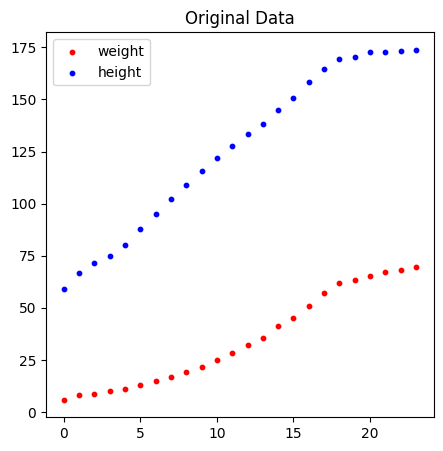

In [2]:
#@title { vertical-output: true}
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(range(len(weight)), weight, color='r', label='weight', s=10)
plt.scatter(range(len(height)), height, color='b', label='height', s=10)
plt.title("Original Data")
plt.legend()
plt.show()

---
## Part 2: Min-Max Normalization (40점)

Min-Max Normalization은 데이터를 0과 1 사이의 값으로 스케일링합니다.

**공식:**
$$x_{normalized} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

---

### 문제 2-1. Min-Max Scaling 함수 구현 [30점]

Min-Max Normalization을 수행하는 함수를 구현합니다.

**문제:** `min_max_scaling` 함수를 완성하세요.

**힌트:**
- `np.min(data)`: 최솟값
- `np.max(data)`: 최댓값

**예상 결과:** 정규화된 데이터의 범위가 0~1

In [9]:
#@title { vertical-output: true}
def min_max_scaling(data):
    """
    Min-Max Normalization

    Parameters:
    - data: 입력 데이터 (numpy array)

    Returns:
    - 0~1 사이로 정규화된 데이터
    """
    # IMPLEMENT HERE
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# 테스트
test_data = np.array([10, 20, 30, 40, 50])
print(f"테스트 데이터: {test_data}")
print(f"정규화 결과: {min_max_scaling(test_data)}")
print(f"예상 결과: [0.   0.25 0.5  0.75 1.  ]")

테스트 데이터: [10 20 30 40 50]
정규화 결과: [0.   0.25 0.5  0.75 1.  ]
예상 결과: [0.   0.25 0.5  0.75 1.  ]


### 문제 2-2. Normalization 적용 및 시각화 [10점]

weight와 height 데이터에 Min-Max Normalization을 적용하고 시각화합니다.

**예상 결과:** 두 데이터 모두 0~1 범위로 스케일링된 산점도

Normalized Weight 범위: 0.00 ~ 1.00
Normalized Height 범위: 0.00 ~ 1.00


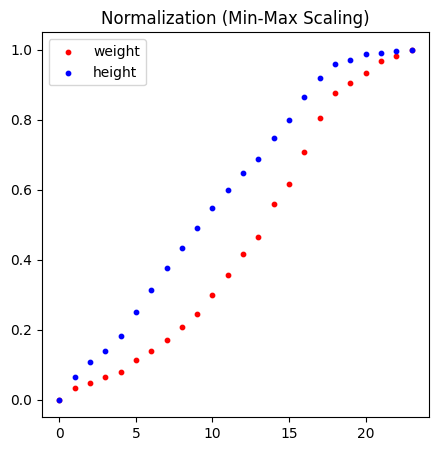

In [10]:
#@title { vertical-output: true}
weight_normalized = min_max_scaling(weight)
height_normalized = min_max_scaling(height)

print(f"Normalized Weight 범위: {weight_normalized.min():.2f} ~ {weight_normalized.max():.2f}")
print(f"Normalized Height 범위: {height_normalized.min():.2f} ~ {height_normalized.max():.2f}")

plt.figure(figsize=(5, 5))
plt.scatter(range(len(weight_normalized)), weight_normalized, color='r', label='weight', s=10)
plt.scatter(range(len(height_normalized)), height_normalized, color='b', label='height', s=10)
plt.title("Normalization (Min-Max Scaling)")
plt.legend()
plt.show()

---
## Part 3: Standardization (Z-Score) (40점)

Standardization은 데이터를 평균 0, 표준편차 1로 변환합니다.

**공식:**
$$x_{standardized} = \frac{x - \mu}{\sigma}$$

여기서 $\mu$는 평균, $\sigma$는 표준편차입니다.

---

### 문제 3-1. Standardization 함수 구현 [30점]

Z-Score Standardization을 수행하는 함수를 구현합니다.

**문제:** `standardization` 함수를 완성하세요.

**힌트:**
- `np.mean(data)`: 평균
- `np.std(data)`: 표준편차

**예상 결과:** 표준화된 데이터의 평균이 약 0, 표준편차가 약 1

In [7]:
#@title { vertical-output: true}
def standardization(data):
    """
    Z-Score Standardization

    Parameters:
    - data: 입력 데이터 (numpy array)

    Returns:
    - 평균 0, 표준편차 1로 표준화된 데이터
    """

    # IMPLEMENT HERE
    return (data - np.mean(data)) / np.std(data)

# 테스트
test_data = np.array([10, 20, 30, 40, 50])
result = standardization(test_data)
print(f"테스트 데이터: {test_data}")
print(f"표준화 결과: {result}")
print(f"결과 평균: {np.mean(result):.4f} (예상: 0)")
print(f"결과 표준편차: {np.std(result):.4f} (예상: 1)")

테스트 데이터: [10 20 30 40 50]
표준화 결과: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
결과 평균: 0.0000 (예상: 0)
결과 표준편차: 1.0000 (예상: 1)


### 문제 3-2. Standardization 적용 및 시각화 [10점]

weight와 height 데이터에 Standardization을 적용하고 시각화합니다.

**예상 결과:** 두 데이터 모두 평균 0을 중심으로 분포하는 산점도

Standardized Weight - 평균: -0.0000, 표준편차: 1.0000
Standardized Height - 평균: -0.0000, 표준편차: 1.0000


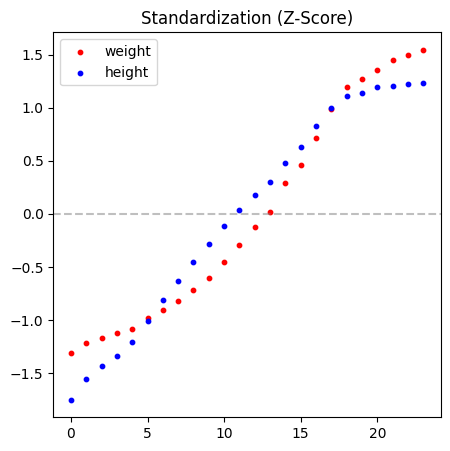

In [8]:
#@title { vertical-output: true}
weight_standardized = standardization(weight)
height_standardized = standardization(height)

print(f"Standardized Weight - 평균: {np.mean(weight_standardized):.4f}, 표준편차: {np.std(weight_standardized):.4f}")
print(f"Standardized Height - 평균: {np.mean(height_standardized):.4f}, 표준편차: {np.std(height_standardized):.4f}")

plt.figure(figsize=(5, 5))
plt.scatter(range(len(weight_standardized)), weight_standardized, color='r', label='weight', s=10)
plt.scatter(range(len(height_standardized)), height_standardized, color='b', label='height', s=10)
plt.title("Standardization (Z-Score)")
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `normalization_학번_이름.ipynb`, `normalization_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---